## Exercises

In these exercises we'll use the same dataset as in the previous block: [Ocean Quality Dataset](https://www.kaggle.com/datasets/vinothkannaece/ocean-quality-dataset)

1. Train an MLP with the same configuration as Scikit but now using PyTorch for the clasification task.
2. Repeat the training with different values of the learning rate and visualize how the loss evolution changes. Remember that this parameter makes sense with values close to 0. **Extra**: Make the plot using the `matplotlib` library.
3. Save the best model. In another cell or Python `script` load it and make predictions without retraining.

In [21]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report

# Càrrega del dataset
df = pd.read_csv("ocean/synthetic_ocean_quality_realistic.csv")

# Selecció de features i target (ajusta els noms al dataset real)
X = df.drop(columns=['Quality']).values
y = df['Quality'].values

# Codificació de l'etiqueta si és categòrica
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print(y)
n_classes = len(encoder.classes_)

# Divisió train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalització
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Conversió a tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test,  dtype=torch.long)


n_features = X_train.shape[1]

model = nn.Sequential(
    nn.Linear(n_features, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, n_classes)
)
# Funció de pèrdua amb pesos

weights = torch.ones(n_classes)
bad_idx = 0
weights[bad_idx] = 10.0
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Training loop
losses = []
epochs = 1000
for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")

# Avaluació
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)
    y_pred_train = model(X_train)
    predicted   = torch.argmax(y_pred_test, dim=1)
    predicted_train   = torch.argmax(y_pred_train, dim=1)
print("TEST")
print(classification_report(
    y_test.numpy(),
    predicted.numpy(),
    target_names=encoder.classes_
))

print("TRAIN")
print(classification_report(
    y_train.numpy(),
    predicted_train.numpy(),
    target_names=encoder.classes_
))


[1 1 1 ... 1 1 1]
Epoch 50/1000 - Loss: 0.6905
Epoch 100/1000 - Loss: 0.6884
Epoch 150/1000 - Loss: 0.6859
Epoch 200/1000 - Loss: 0.6828
Epoch 250/1000 - Loss: 0.6791
Epoch 300/1000 - Loss: 0.6744
Epoch 350/1000 - Loss: 0.6685
Epoch 400/1000 - Loss: 0.6614
Epoch 450/1000 - Loss: 0.6532
Epoch 500/1000 - Loss: 0.6440
Epoch 550/1000 - Loss: 0.6348
Epoch 600/1000 - Loss: 0.6263
Epoch 650/1000 - Loss: 0.6191
Epoch 700/1000 - Loss: 0.6133
Epoch 750/1000 - Loss: 0.6089
Epoch 800/1000 - Loss: 0.6055
Epoch 850/1000 - Loss: 0.6029
Epoch 900/1000 - Loss: 0.6006
Epoch 950/1000 - Loss: 0.5987
Epoch 1000/1000 - Loss: 0.5970
              precision    recall  f1-score   support

         Bad       0.20      0.57      0.30      1831
        Good       0.95      0.77      0.85     18169

    accuracy                           0.75     20000
   macro avg       0.57      0.67      0.57     20000
weighted avg       0.88      0.75      0.80     20000

TRAIN
              precision    recall  f1-score   sup

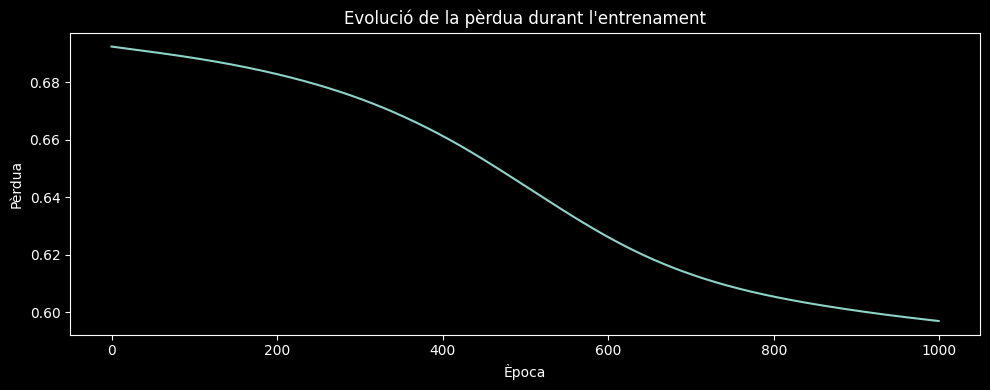

In [22]:
import matplotlib.pyplot as plt
# Visualització
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Època')
plt.ylabel('Pèrdua')
plt.title('Evolució de la pèrdua durant l\'entrenament')
plt.tight_layout()
plt.show()

Guardar i Carregar el model

In [23]:
torch.save(model.state_dict(), 'model.pth')

In [24]:
# Load the weights
model.load_state_dict(torch.load('model.pth'))
model.eval()

Sequential(
  (0): Linear(in_features=7, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=2, bias=True)
)